## Случайные марковские процессы: цепь по буквам текста и HMM для числового ряда

Марковская цепь описывает не числовое значение ряда, а переключение состояний:
следующее состояние зависит только от текущего, а не от всей предыстории. Задание
состоит из двух частей.

В первой части состояния - это буквы. По тексту «Войны и мира» строится матрица
переходных вероятностей между буквами, и через нее считается вероятность
конкретной строки из четырех символов и генерируется слово из восьми.

Во второй части состояния скрыты. К числовому ряду из прошлых работ применяется скрытая марковская модель: сколько в ряде режимов, чем они
различаются и можно ли построить прогноз по средним этих режимов.

Данные: четыре тома «Войны и мира» и недельный
индекс Доу-Джонса из папки `Series`

### Задача 1. Загрузка текста

Нужен большой русский текст. По закону больших чисел: чем больше объем, тем ближе
оцененные по нему частоты пар букв к истинным переходным вероятностям. Поэтому
берутся все четыре тома сразу, а не один

In [1]:
import re
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from urllib.request import urlretrieve

warnings.filterwarnings('ignore')
# hmmlearn печатает сообщения о недосходимости EM в лог, а не в warnings;
# на GitHub такой поток stderr рисуется красным блоком, поэтому глушим уровнем
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)
sns.set_style('whitegrid')

БАЗА = ('https://raw.githubusercontent.com/netology-code/ds3-spring-2018/'
        'master/7.%20Time_series/7.4/war_and_peace')

тома = []
for н in range(1, 5):
    файл = Path(f'tom_{н}.txt')
    if not файл.exists():                       # скачиваем один раз, дальше с диска
        urlretrieve(f'{БАЗА}/tom_{н}.txt', файл)
    тома.append(файл.read_text(encoding='utf-8'))

сырой = ''.join(тома)
букв_всего = sum(c.isalpha() for c in сырой)
print('томов загружено:', len(тома))
print('символов всего:', len(сырой), '| из них букв:', букв_всего)
print('начало первого тома:')
print(сырой[:160].replace(chr(10), ' '))

томов загружено: 4
символов всего: 2993415 | из них букв: 2373618
начало первого тома:
Annotation   Лев Толстой  Война и Мир  Том 1      * * *    Том IЧАСТЬ ПЕРВАЯI  II  III  IV  V  VI  VII  VIII  IX  X  XI  XII  XIII  XIV  XV  XVI  XVII  XVIII  X


**Вывод по Задаче 1:** «Война и мир» Л. Н. Толстого, четыре тома, вместе около
3.0 млн символов и 2.4 млн букв. Корпус большой - по закону больших чисел на таком
объеме частоты пар букв уже устойчивы

### Задача 2. Очистка текста

По условию в тексте остаются только русские буквы и пробел. Порядок такой: перевод
в нижний регистр, замена всего, что не буква и не пробел, на пробел, схлопывание
подряд идущих пробелов в один.

В русском алфавите 33 буквы, но одну из них - редкую, на долю процента текста -
в письме обычно не отличают от «е». Она приводится к «е»: отдельным состоянием
она дала бы почти пустую строку матрицы, а в диапазон `[а-я]` регулярного
выражения она не попадает, и без замены каждое такое вхождение рвало бы слово
пополам

In [2]:
низ = сырой.lower()
латинских = sum(c.isascii() and c.isalpha() for c in низ)
редкая_е = '\u0451'                        # 'е' с двумя точками, вне диапазона [а-я]
редких = низ.count(редкая_е)

низ = низ.replace(редкая_е, 'е')
чистый = re.sub(r'[^а-я ]', ' ', низ)
чистый = re.sub(r'\s+', ' ', чистый).strip()

доля = редких / sum(c.isalpha() for c in сырой) * 100
print(f'латинских букв в оригинале: {латинских} - французские вставки, убраны при очистке')
print(f'приведено к обычной «е»: {редких} букв ({доля:.2f}% всех букв)')
print(f'после очистки: {len(чистый)} символов, из них пробелов {чистый.count(" ")} '
      f'({чистый.count(" ") / len(чистый) * 100:.0f}%)')
print('фрагмент очищенного текста:')
print(чистый[500:760])

латинских букв в оригинале: 72638 - французские вставки, убраны при очистке
приведено к обычной «е»: 1015 букв (0.04% всех букв)
после очистки: 2748902 символов, из них пробелов 447922 (16%)
фрагмент очищенного текста:
е я вижу что я вас пугаю садитесь и рассказывайте так говорила в июле года известная анна павловна шерер фрейлина и приближенная императрицы марии феодоровны встречая важного и чиновного князя василия первого приехавшего на ее вечер анна павловна кашляла неско


**Вывод по Задаче 2:** после очистки остается около 2.75 млн символов, каждый
шестой - пробел. Французские вставки (порядка 73 тысяч латинских букв - «Война и
мир» местами написана по-французски) ушли вместе со знаками препинания. Алфавит
свелся к 32 буквам и пробелу - **33 состояния**. Фрагмент читается как сплошной
русский текст без знаков препинания и заглавных: это и есть вход для цепи

### Задача 3. Матрица переходных вероятностей

Пространство состояний - 33 символа. По тексту идет окно длины два: для каждой
пары «текущий символ - следующий» соответствующая клетка матрицы увеличивается
на единицу. Потом каждая строка делится на свою сумму - получается вероятность
того, что из символа `i` цепь перейдет в символ `j`, и сумма по строке равна
единице (перейти куда-то цепь обязана)

In [3]:
СОСТОЯНИЯ = 'абвгдежзийклмнопрстуфхцчшщъыьэюя '
ПОЗ = {с: i for i, с in enumerate(СОСТОЯНИЯ)}
K = len(СОСТОЯНИЯ)

счетчик = np.zeros((K, K))
коды = [ПОЗ[с] for с in чистый]
for предыдущий, следующий in zip(коды[:-1], коды[1:]):
    счетчик[предыдущий, следующий] += 1

P = счетчик / счетчик.sum(axis=1, keepdims=True)

print('размер матрицы:', P.shape)
print('пар символов учтено:', int(счетчик.sum()))
print('каждая строка суммируется в 1:', np.allclose(P.sum(axis=1), 1))
print('пар, не встретившихся ни разу:', int((счетчик == 0).sum()), 'из', K * K)
print()
for с in ['п', 'б', 'ъ', ' ']:
    строка = P[ПОЗ[с]]
    топ = np.argsort(строка)[::-1][:4]
    print(f'чаще всего из {с!r}: ' + ', '.join(f'{СОСТОЯНИЯ[j]!r} {строка[j]:.3f}' for j in топ))

размер матрицы: (33, 33)
пар символов учтено: 2748901
каждая строка суммируется в 1: True
пар, не встретившихся ни разу: 273 из 1089

чаще всего из 'п': 'о' 0.384, 'р' 0.278, 'е' 0.110, 'а' 0.052
чаще всего из 'б': 'ы' 0.273, 'о' 0.147, 'е' 0.142, 'р' 0.076
чаще всего из 'ъ': 'е' 0.470, 'ю' 0.282, 'я' 0.246, ' ' 0.001
чаще всего из ' ': 'с' 0.097, 'н' 0.096, 'п' 0.095, 'в' 0.091


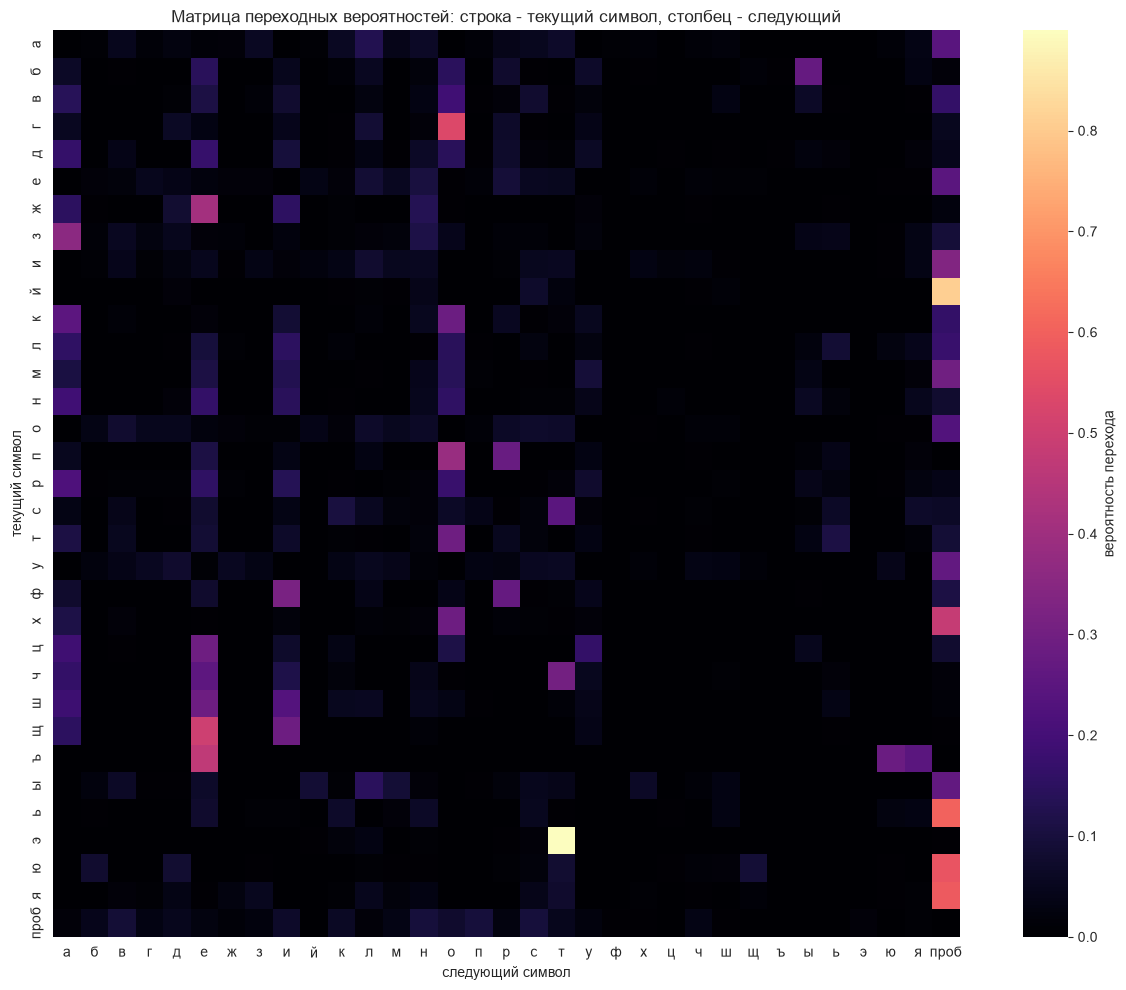

In [4]:
подписи = [с if с != ' ' else 'проб' for с in СОСТОЯНИЯ]
таблица_P = pd.DataFrame(P, index=подписи, columns=подписи)

plt.figure(figsize=(13, 10))
sns.heatmap(таблица_P, cmap='magma', square=True,
            cbar_kws={'label': 'вероятность перехода'})
plt.title('Матрица переходных вероятностей: строка - текущий символ, столбец - следующий')
plt.xlabel('следующий символ')
plt.ylabel('текущий символ')
plt.tight_layout()
plt.show()

**Вывод по Задаче 3:** матрица 33 на 33, построена по 2.75 млн пар. Строки
суммируются в единицу.

273 пары из 1089 не встретились ни разу - четверть матрицы строго нулевая. Это стыки
согласных, которых в русских словах практически нет (`гб`, `бф`, `вф`), и твердый
знак, после которого практически всегда идут `е`, `ю` или `я` (`p(ъ->е) = 0.470`,
`p(ъ->ю) = 0.282`, `p(ъ->я) = 0.246`, на все остальное вместе меньше процента).

Самые яркие клетки читаются как русская фонетика: `p(п->о) = 0.384` и
`p(п->р) = 0.278` - «по» и «пр» среди самых частых сочетаний в языке. Из пробела
цепь уходит в `с`, `н`, `п`, `в` - буквы, с которых чаще всего начинаются слова.
То есть матрица переходов первого порядка - это уже статистический отпечаток
языка, хотя она смотрит всего на один предыдущий символ

### Задача 4. Вероятность строки из четырех символов «п...р»

Считается вероятность встретить строку из четырех символов, которая начинается на
`п` и заканчивается на `р`. У первого символа предыдущего нет, поэтому ему дается
априорная вероятность - равномерная `1/33`, как в формуле для траектории цепи.
Две средние буквы перебираются по всем вариантам.

Равномерное начало - допущение: у буквы «п» есть и своя частота в тексте. Поэтому
та же вероятность считается вторым разом, с этой частотой вместо `1/33`.

Та же сумма по средним буквам - это элемент `(п, р)` матрицы `P` в третьей степени
(теорема о вероятности перехода за `n` шагов). Оба способа считаются и сверяются

In [5]:
начало, конец = ПОЗ['п'], ПОЗ['р']
априори = 1 / K

# способ 1: перебор обеих средних букв
сумма = sum(P[начало, c1] * P[c1, c2] * P[c2, конец]
            for c1 in range(K) for c2 in range(K))
вероятность_перебором = априори * сумма

# способ 2: элемент (п, р) матрицы P в третьей степени - три перехода на строку из 4 букв
P3 = np.linalg.matrix_power(P, 3)
вероятность_степенью = априори * P3[начало, конец]

# равномерное начало завышает редкие буквы и занижает частые: у «п» частота своя
частота_п = чистый.count('п') / len(чистый)
вероятность_по_частоте = частота_п * P3[начало, конец]

print(f'P(из п в р за 3 шага)            = {P3[начало, конец]:.5f}')
print(f'перебор середины = P^3           : {np.isclose(вероятность_перебором, вероятность_степенью)}')
print(f'P(строка «п??р» из 4 символов)   = {вероятность_перебором:.6f}')
print(f'примерно одна такая строка на     {round(1 / вероятность_перебором)}')
print(f'частота «п» в тексте             = {частота_п:.5f}')
print(f'то же с частотой «п» вместо 1/33 = {вероятность_по_частоте:.6f}')
print()
вклады = sorted(
    ((f'п{СОСТОЯНИЯ[c1]}{СОСТОЯНИЯ[c2]}р',
      априори * P[начало, c1] * P[c1, c2] * P[c2, конец])
     for c1 in range(K) for c2 in range(K)),
    key=lambda пара: -пара[1])
доля_топа = sum(в for _, в in вклады[:6]) / вероятность_перебором * 100
print(f'основной вклад дают (первые 6 строк - {доля_топа:.0f}% всей вероятности):')
for строка, вес in вклады[:6]:
    print(f'  {строка!r}: {вес:.2e}')

P(из п в р за 3 шага)            = 0.03226
перебор середины = P^3           : True
P(строка «п??р» из 4 символов)   = 0.000977
примерно одна такая строка на     1023
частота «п» в тексте             = 0.02203
то же с частотой «п» вместо 1/33 = 0.000711

основной вклад дают (первые 6 строк - 45% всей вероятности):
  'прер': 1.23e-04
  'прор': 9.37e-05
  'прар': 7.63e-05
  'по р': 6.76e-05
  'потр': 4.18e-05
  'попр': 4.10e-05


**Вывод по Задаче 4:** условная вероятность перейти из `п` в `р` ровно за три
шага - **0.0323**. С равномерным началом `1/33` вероятность строки «п??р» из
четырех символов - **0.000977**, примерно одна такая строка на тысячу.

Ответ зависит от того, что взято за вероятность первого символа. Буква «п»
встречается в тексте с частотой **0.022** - реже, чем одна тридцать третья, - и с
ней та же строка получается **0.000711**, на четверть меньше. Это и есть цена
допущения о равномерном начале.

Перебор двух средних букв и элемент `P^3` совпали до машинной точности - тождество
«матрица переходов за три шага равна кубу матрицы» подтвердилось на данных.

Шесть самых вероятных строк дают почти половину всей вероятности, и все они
читаются как куски настоящих слов: `прер`, `прор`, `прар` (приставки «пре-»,
«про-», «пра-» с продолжением на `р`), `по р` («по» и начало следующего слова),
`потр`, `попр`. Цепь собирает массу на реальных сочетаниях, а не размазывает
ее ровно

### Задача 5. Генерация слова с «б» длиной восемь символов

Генерация реализации цепи: первый символ фиксируется как `б`, дальше каждый
следующий символ берется случайно из строки матрицы `P` для текущего символа.
Всего восемь символов

In [6]:
def сгенерировать(первая, длина, seed):
    np.random.seed(seed)
    слово = [первая]
    for _ in range(длина - 1):
        текущий = ПОЗ[слово[-1]]
        слово.append(np.random.choice(list(СОСТОЯНИЯ), p=P[текущий]))
    return ''.join(слово)


print('слово из 8 символов, начинается с «б»:')
print('  ', repr(сгенерировать('б', 8, seed=0)))
print()
print('еще несколько реализаций с разным seed:')
for s in range(1, 9):
    получилось = сгенерировать('б', 8, seed=s)
    пробел = ' пробел внутри' if ' ' in получилось.strip() or получилось.endswith(' ') else ''
    print(f'  seed={s}: {получилось!r}{пробел}')

слово из 8 символов, начинается с «б»:
   'бростосо'

еще несколько реализаций с разным seed:
  seed=1: 'боталадв'
  seed=2: 'бобриней'
  seed=3: 'брой тьк' пробел внутри
  seed=4: 'бя шкое ' пробел внутри
  seed=5: 'би дыму ' пробел внутри
  seed=6: 'былядато'
  seed=7: 'бе м это' пробел внутри
  seed=8: 'бы тоебо' пробел внутри


**Вывод по Задаче 5:** при `seed = 0` получилось **`бростосо`** - произносимое
псевдослово: слоги открытые (`бро-сто-со`), а `бр` и `ст` - обычные для русского
начала слога.

При других `seed` цепь ставит пробел в середине (`брой тьк`, `бе м это`).
Это ожидаемо: у модели первого порядка нет понятия «слово», ее попросили выдать
восемь символов, а пробел для нее - такое же состояние, в которое можно перейти
из `б`, `о` и так далее со своей вероятностью. Цепь воспроизводит локальную
статистику букв, но не структуру слова: памяти в один символ не хватает, чтобы
знать, где цепь находится внутри слова

### Задача 6. Оценка числового ряда через скрытую марковскую модель

Дальше состояния скрыты, а ряд числовой. Взят ряд из предыдущих работ модуля -
**недельный индекс Доу-Джонса**, 162 точки с июля 1971 по август 1974: рост до
пика начала 1973 года и падение 1973-1974. Гауссова HMM считает, что ряд в каждый
момент находится в одном из нескольких скрытых состояний, и каждому состоянию
отвечает свое нормальное распределение со своим средним. «Оценить ряд через HMM»
здесь - определить, сколько состояний ему нужно и каким рыночным режимам они
соответствуют.

Обучение HMM идет методом EM, а он чувствителен к начальному приближению: разные
старты сходятся к разным решениям. Поэтому каждая модель обучается 30 раз с разными
случайными стартами, и берется та, у которой правдоподобие выборки максимально

In [7]:
from hmmlearn.hmm import GaussianHMM

дж = pd.read_csv('weekly-closings-of-the-dowjones-.csv').dropna()
дата = pd.to_datetime(дж['Week'] + '-1', format='%G-W%V-%u')
индекс = pd.Series(дж['Close'].astype(float).values, index=дата)
Ряд = индекс.values.reshape(-1, 1)

print('точек:', len(Ряд), '| с', дата.iloc[0].date(), 'по', дата.iloc[-1].date())
print('индекс на закрытии: от', индекс.min(), 'до', индекс.max())


def лучшая_hmm(данные, число_состояний, попыток=30):
    """EM неустойчив к старту: обучаем много раз, берем лучшую по правдоподобию.
    Возвращает еще и долю стартов, сошедшихся к этому же оптимуму."""
    итоги = []
    for seed in range(попыток):
        m = GaussianHMM(n_components=число_состояний, covariance_type='diag',
                        n_iter=1000, tol=1e-4, random_state=seed)
        m.fit(данные)
        итоги.append((m.score(данные), m))
    лучший_score, лучшая = max(итоги, key=lambda пара: пара[0])
    доля_к_оптимуму = sum(s >= лучший_score - 1.0 for s, _ in итоги) / попыток
    return лучшая, доля_к_оптимуму

точек: 162 | с 1971-07-05 по 1974-08-05
индекс на закрытии: от 752.58 до 1047.49


In [8]:
модели = {k: лучшая_hmm(Ряд, k) for k in range(1, 7)}

сравнение = []
for k, (m, доля) in модели.items():
    score = m.score(Ряд)
    параметров = k * k - 1 + k + k          # переходы + старт + средние + дисперсии
    сравнение.append({
        'состояний': k,
        'log-правдоподобие': round(score, 1),
        'AIC': round(-2 * score + 2 * параметров, 1),
        'BIC': round(-2 * score + параметров * np.log(len(Ряд)), 1),
        'мин. p(остаться)': round(float(m.transmat_.diagonal().min()), 3),
        'переключений': int((np.diff(m.predict(Ряд)) != 0).sum()),
        'стартов к оптимуму': f'{round(доля * 30)}/30',
    })
сравнение = pd.DataFrame(сравнение)
print(сравнение.to_string(index=False))

 состояний  log-правдоподобие    AIC    BIC  мин. p(остаться)  переключений стартов к оптимуму
         1             -894.3 1792.5 1798.7             1.000             0              30/30
         2             -820.6 1655.3 1676.9             0.973             4              20/30
         3             -786.7 1601.4 1644.6             0.924             6              23/30
         4             -752.0 1550.0 1621.0             0.899             9              12/30
         5             -737.1 1542.2 1647.2             0.567            26               1/30
         6             -725.0 1543.9 1689.0             0.566            37               1/30


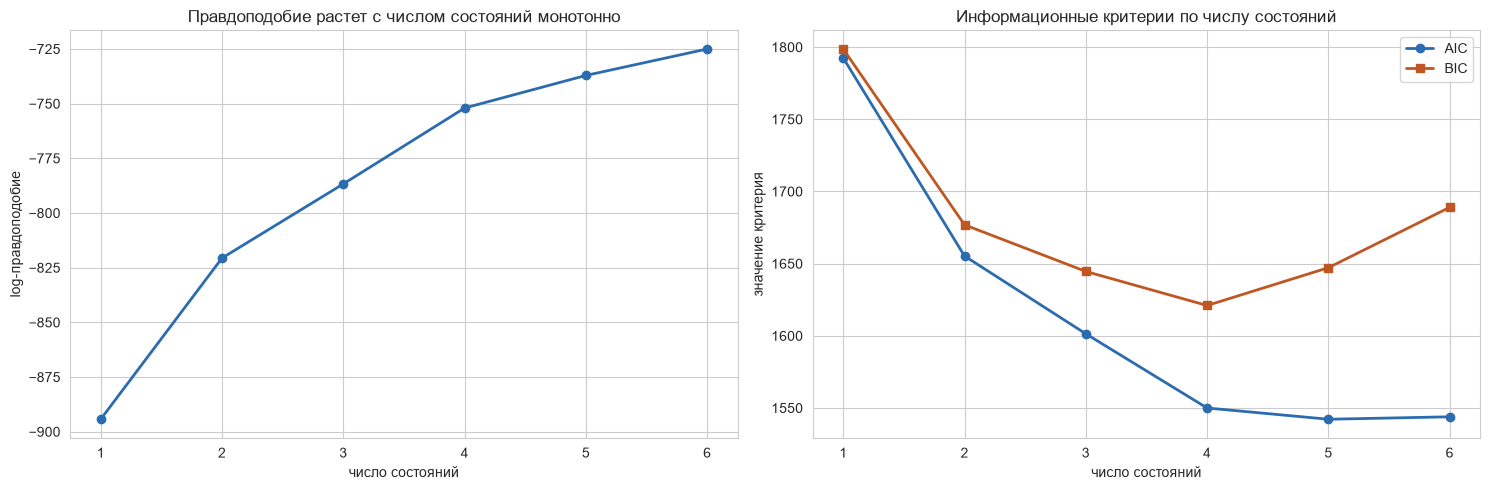

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(сравнение['состояний'], сравнение['log-правдоподобие'], marker='o', lw=2, color='#2b6cb0')
ax[0].set_title('Правдоподобие растет с числом состояний монотонно')
ax[0].set_xlabel('число состояний')
ax[0].set_ylabel('log-правдоподобие')
ax[1].plot(сравнение['состояний'], сравнение['AIC'], marker='o', lw=2, label='AIC', color='#2b6cb0')
ax[1].plot(сравнение['состояний'], сравнение['BIC'], marker='s', lw=2, label='BIC', color='#c05621')
ax[1].set_title('Информационные критерии по числу состояний')
ax[1].set_xlabel('число состояний')
ax[1].set_ylabel('значение критерия')
ax[1].legend()
plt.tight_layout()
plt.show()

Критерии тянут к четырем-пяти состояниям, но перед выбором надо посмотреть на сами
модели: не рассыпается ли структура режимов. Берем три состояния и сверяем их с
моделями на четыре и пять

In [10]:
hmm3, доля3 = модели[3]
порядок = np.argsort(hmm3.means_.ravel())              # состояния по возрастанию среднего
средние = hmm3.means_.ravel()[порядок]
разброс = np.sqrt(hmm3.covars_.ravel()[порядок])
переходы = hmm3.transmat_[np.ix_(порядок, порядок)]
перекод = {старое: новое for новое, старое in enumerate(порядок)}
состояние = np.array([перекод[s] for s in hmm3.predict(Ряд)])

print('три состояния, средние:      ', np.round(средние, 1))
print('разброс внутри состояния:    ', np.round(разброс, 1))
print('расстояние между соседними:  ', np.round(np.diff(средние), 1))
print('матрица переходов:')
print(np.round(переходы, 3))
print('среднее время в состоянии, недель:', np.round(1 / (1 - переходы.diagonal()), 1))
print('стационарное распределение:       ', np.round(hmm3.get_stationary_distribution()[порядок], 3))
print('недель в каждом состоянии:         ', [int((состояние == i).sum()) for i in range(3)])
print()
for k in (4, 5):
    m, доля = модели[k]
    ср = np.sort(m.means_.ravel())
    print(f'{k} состояния: средние {np.round(ср, 1)}, '
          f'мин. p(остаться) {m.transmat_.diagonal().min():.3f}, '
          f'переключений {int((np.diff(m.predict(Ряд)) != 0).sum())}, '
          f'стартов к оптимуму {round(доля * 30)}/30')

три состояния, средние:       [ 863.7  949.8 1017. ]
разброс внутри состояния:     [38.2 17.9 18.6]
расстояние между соседними:   [86.  67.2]
матрица переходов:
[[0.977 0.023 0.   ]
 [0.035 0.948 0.017]
 [0.    0.076 0.924]]
среднее время в состоянии, недель: [43.8 19.3 13.2]
стационарное распределение:        [0.553 0.364 0.083]
недель в каждом состоянии:          [89, 60, 13]

4 состояния: средние [ 834.5  894.5  950.9 1017.2], мин. p(остаться) 0.899, переключений 9, стартов к оптимуму 12/30
5 состояния: средние [ 810.6  850.7  895.8  950.7 1017.1], мин. p(остаться) 0.567, переключений 26, стартов к оптимуму 1/30


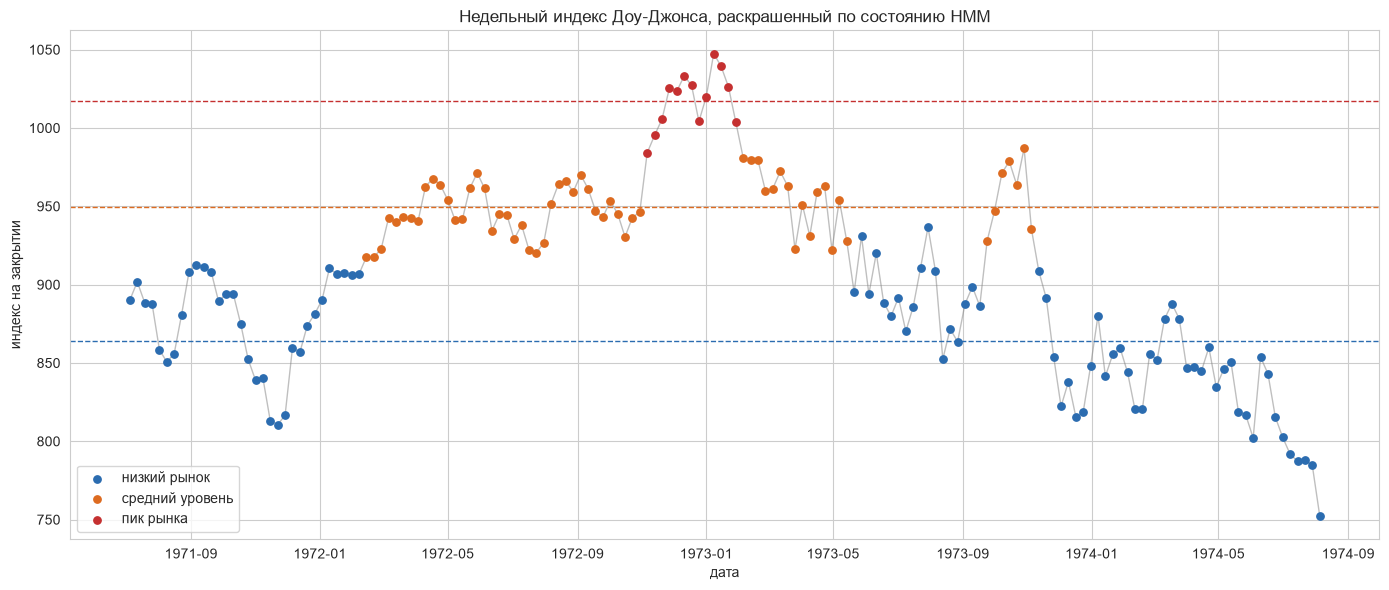

In [11]:
цвета = ['#2b6cb0', '#dd6b20', '#c53030']
имена = ['низкий рынок', 'средний уровень', 'пик рынка']

plt.figure(figsize=(14, 6))
plt.plot(индекс.index, индекс.values, color='gray', lw=1, alpha=0.5, zorder=1)
for i in range(3):
    маска = состояние == i
    plt.scatter(индекс.index[маска], индекс.values[маска], color=цвета[i], s=28, label=имена[i], zorder=2)
    plt.axhline(средние[i], color=цвета[i], lw=1, ls='--', zorder=1)
plt.title('Недельный индекс Доу-Джонса, раскрашенный по состоянию HMM')
plt.xlabel('дата')
plt.ylabel('индекс на закрытии')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 6:** log-правдоподобие растет с числом состояний монотонно, AIC
минимален при пяти состояниях, BIC при четырех - но минимум критерия здесь
достается моделям, которые описывают уже не режимы.

При пяти состояниях минимальная вероятность остаться в том же состоянии падает до
**0.57**, а число переключений на 162 неделях подскакивает до **26**: модель
гоняется за недельными колебаниями. При четырех состояниях лишнее состояние делит
низкий рынок на подуровни 834 и 894, сегментация первого года рассыпается на пять
коротких блоков, и лучший оптимум там находят лишь 12 стартов из 30 против 23 из
30 для трех состояний - решение на четыре состояния заметно менее устойчиво.

Три состояния - средние **864, 950, 1017**, разброс внутри каждого 18-38 пунктов,
соседние средние разведены на 67 и 86 пунктов (не меньше двух стандартных отклонений
даже по самому широкому состоянию - состояния различимы). Все три устойчивы:
вероятность остаться 0.92-0.98, среднее время пребывания от 13 до 44 недель. За 162
недели всего **шесть переключений**.

Раскраска ложится на известную историю рынка: низкий уровень до февраля 1972-го,
рост к среднему через 1972 год, пик из тринадцати недель на рубеже 1972-1973 годов
(исторический максимум Доу-Джонса - январь 1973), затем спуск на средний и низкий
уровни с одним коротким отскоком осенью 1973-го - медвежий рынок 1973-1974.
Стационарное распределение (0.55 / 0.36 / 0.08) говорит, что большую часть времени
рынок проводит на среднем уровне и ниже, а на пике бывает недолго.

То есть «через HMM» ряд выглядит как три устойчивых ценовых режима с редкими
переходами, а не как плавный тренд

### Задача 7. Наивный прогноз через средние состояний

Прогноз строится только по средним состояний. Разделение - **по времени**:
временной ряд нельзя перемешивать. Последние 26 недель откладываются, HMM заново
обучается на первых 136. Прогноз берется в двух вариантах: остаться в последнем
распознанном состоянии (тогда прогноз - плоская линия на его среднем) или гнать
матрицу переходов на 26 шагов вперед и брать среднее по получившемуся
распределению состояний. Для сравнения - наивное правило «завтра как сегодня» и
линейный дрейф по последним неделям

In [12]:
h = 26
обучение, проверка = индекс.values[:-h], индекс.values[-h:]

hmm_tr, _ = лучшая_hmm(обучение.reshape(-1, 1), 3)
пор = np.argsort(hmm_tr.means_.ravel())
ср_tr = hmm_tr.means_.ravel()[пор]
A = hmm_tr.transmat_[np.ix_(пор, пор)]
перекод_tr = {старое: новое for новое, старое in enumerate(пор)}
сост_tr = np.array([перекод_tr[s] for s in hmm_tr.predict(обучение.reshape(-1, 1))])

# восстановление обучающей части ступенькой из средних состояний
ступенька = ср_tr[сост_tr]
rmse_ступеньки = np.sqrt(((ступенька - обучение) ** 2).mean())

# прогноз строится только из матрицы переходов и средних - фактического последнего
# значения ряда в нем нет
последнее = сост_tr[-1]
прогноз_плоский = np.repeat(ср_tr[последнее], h)

распределение = np.zeros(3)
распределение[последнее] = 1
прогноз_переходами = []
for _ in range(h):
    распределение = распределение @ A
    прогноз_переходами.append(распределение @ ср_tr)
прогноз_переходами = np.array(прогноз_переходами)

наклон = (обучение[-1] - обучение[-13]) / 12
базовые = {
    'наивное «как сегодня»': np.repeat(обучение[-1], h),
    'линейный дрейф': обучение[-1] + наклон * np.arange(1, h + 1),
}


def rmse(прогноз):
    return round(float(np.sqrt(((прогноз - проверка) ** 2).mean())), 1)


стационарное = float(hmm_tr.get_stationary_distribution()[пор] @ ср_tr)
print(f'состояние в конце обучения: {последнее} (среднее {ср_tr[последнее]:.0f})')
print(f'RMSE ступеньки на обучении: {rmse_ступеньки:.1f}')
print()
print('RMSE прогноза на 26 недель:')
print(f'  HMM, остаемся в последнем состоянии : {rmse(прогноз_плоский)}')
print(f'  HMM, переходы вперед                : {rmse(прогноз_переходами)}')
for имя, пр in базовые.items():
    print(f'  {имя:35s}: {rmse(пр)}')
print()
print(f'прогноз переходами дрейфует: {прогноз_переходами[0]:.0f} -> {прогноз_переходами[-1]:.0f}, '
      f'к стационарному среднему {стационарное:.0f}')
print(f'факт на проверке:            {проверка[0]:.0f} -> {проверка[-1]:.0f}')

состояние в конце обучения: 0 (среднее 878)
RMSE ступеньки на обучении: 24.8

RMSE прогноза на 26 недель:
  HMM, остаемся в последнем состоянии : 58.2
  HMM, переходы вперед                : 79.5
  наивное «как сегодня»              : 35.5
  линейный дрейф                     : 64.8

прогноз переходами дрейфует: 880 -> 911, к стационарному среднему 923
факт на проверке:            820 -> 753


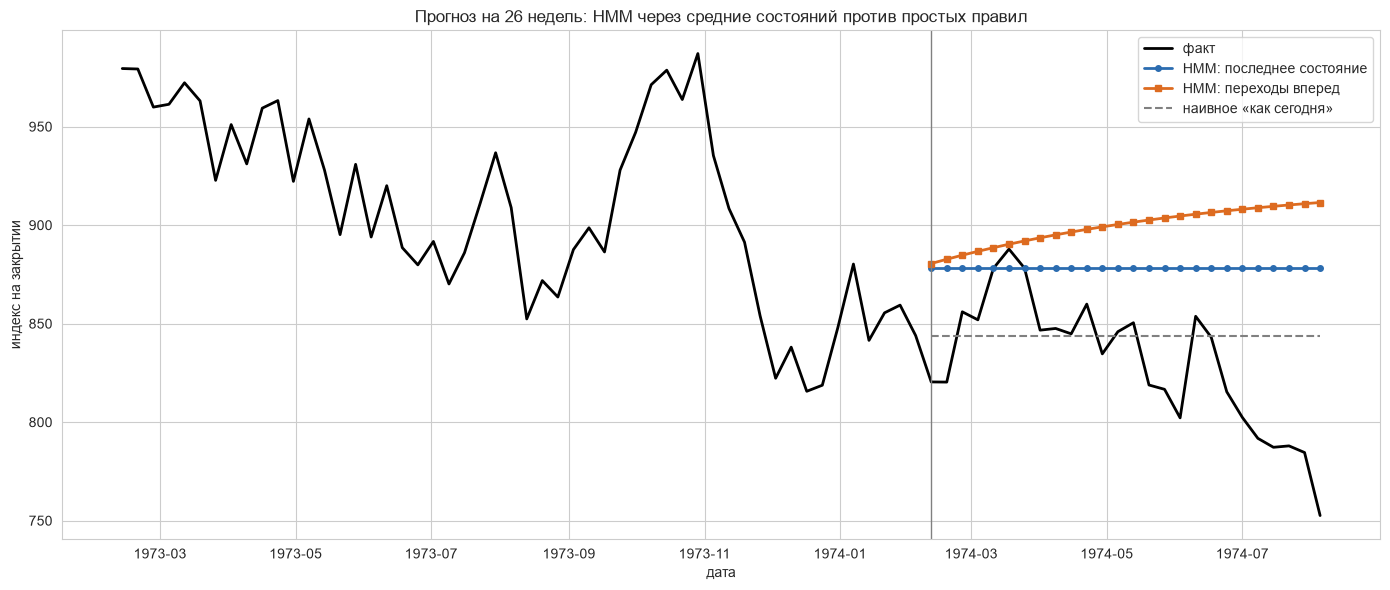

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(индекс.index[-3 * h:], индекс.values[-3 * h:], color='black', lw=2, label='факт')
plt.plot(индекс.index[-h:], прогноз_плоский, color='#2b6cb0', lw=2, marker='o', ms=4,
         label='HMM: последнее состояние')
plt.plot(индекс.index[-h:], прогноз_переходами, color='#dd6b20', lw=2, marker='s', ms=4,
         label='HMM: переходы вперед')
plt.plot(индекс.index[-h:], базовые['наивное «как сегодня»'], color='gray', lw=1.5, ls='--',
         label='наивное «как сегодня»')
plt.axvline(индекс.index[-h], color='gray', lw=1)
plt.title('Прогноз на 26 недель: HMM через средние состояний против простых правил')
plt.xlabel('дата')
plt.ylabel('индекс на закрытии')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 7:** на обучающей части ступенька из средних состояний
приближает ряд с RMSE **24.8** - как описание прошлого через три уровня HMM
работает.

С прогнозом иначе. В конце обучения ряд распознан как низкое состояние (среднее
878). Вариант «остаемся в состоянии» дает плоские 878; вариант «переходы вперед»
уводит прогноз с 880 до 911 - к стационарному среднему 923, потому что из низкого
состояния каждую неделю часть вероятности перетекает в средний и верхний уровни.
Ни один из вариантов не использует ни последнее значение ряда, ни его наклон.

Настоящий ряд эти 26 недель падал: с 820 до 753, это хвост медвежьего рынка. Оба
прогноза HMM смотрят не туда. RMSE: переходы вперед **79.5**, плоский **58.2**,
линейный дрейф **64.8**, наивное «как сегодня» **35.5**.

Правило «завтра как сегодня» точнее всех с большим отрывом - недельные приращения
индекса на этом отрезке почти непредсказуемы, и любая модель со средним, к
которому она тянется, проигрывает угадыванию «без изменений». Прогноз HMM собран
только из матрицы переходов и средних состояний: от всей траектории в нем остается
одно распознанное состояние последней недели, а фактического последнего значения
ряда нет вовсе. Гауссова HMM полезна как детектор смены режима, а не как
инструмент числового прогноза трендового ряда

### Дополнительный эксперимент (вне рамок задания)

Две проверки в стороне от задания: поднять порядок цепи для генерации букв и
применить HMM не к уровню ряда, а к его недельной доходности

**Марковская цепь второго порядка.** В Задаче 5 следующий символ зависел от одного
предыдущего. Если смотреть на два предыдущих, контекст становится информативнее.
Строится таблица «пара символов - следующий символ», и то же слово с «б» и те же
фрагменты генерируются с контекстом из двух букв. Качество меряется долей
сгенерированных «слов», которые реально встречаются в тексте

In [14]:
from collections import Counter

тройки = Counter(zip(чистый, чистый[1:], чистый[2:]))   # (символ, символ, следующий) -> сколько раз
контексты = {}
for (a, b, c), n in тройки.items():
    контексты.setdefault((a, b), np.zeros(K))[ПОЗ[c]] += n
P2 = {пара: счет / счет.sum() for пара, счет in контексты.items()}
print('уникальных пар-контекстов:', len(P2), 'из', K * K, 'возможных')


def сгенерировать2(первая, длина, seed):
    np.random.seed(seed)
    слово = list(первая)
    while len(слово) < длина:
        пара = (слово[-2], слово[-1]) if len(слово) >= 2 else None
        p = P2[пара] if пара in P2 else P[ПОЗ[слово[-1]]]   # незнакомый контекст - откат к 1-му порядку
        слово.append(СОСТОЯНИЯ[np.random.choice(K, p=p)])
    return ''.join(слово)


print()
print('слово из 8 символов с «б» - первый порядок против второго:')
for s in range(6):
    print(f'  seed={s}: {сгенерировать("б", 8, s)!r}   ->   {сгенерировать2("б", 8, s)!r}')
print()
print('фрагмент 40 символов:')
for s in range(3):
    print(f'  1-й: {сгенерировать("б", 40, s)!r}')
    print(f'  2-й: {сгенерировать2("б", 40, s)!r}')

уникальных пар-контекстов: 816 из 1089 возможных

слово из 8 символов с «б» - первый порядок против второго:
  seed=0: 'бростосо'   ->   'броприст'
  seed=1: 'боталадв'   ->   'бопалага'
  seed=2: 'бобриней'   ->   'боволоже'
  seed=3: 'брой тьк'   ->   'брое туз'
  seed=4: 'бя шкое '   ->   'бя чтоля'
  seed=5: 'би дыму '   ->   'бите не '

фрагмент 40 символов:
  1-й: 'бростосо че но вавя т спратв нилю обух ч'
  2-й: 'бропристь и не ведших смогог нем мого о '
  1-й: 'боталадвинни дувсораку и тьеги во ноко б'
  2-й: 'бопалагами лужурно вит и тузак врукой са'
  1-й: 'бобриней илусера то вововатедемодонинчна'
  2-й: 'боволожетом наясь ние врадойскакорому на'


In [15]:
словарь = set(чистый.split())


def доля_настоящих(порядок, символов=6000, seed=0):
    np.random.seed(seed)
    цепь = [' ']
    while len(цепь) < символов:
        if порядок == 1 or len(цепь) < 2 or (цепь[-2], цепь[-1]) not in P2:
            p = P[ПОЗ[цепь[-1]]]
        else:
            p = P2[(цепь[-2], цепь[-1])]
        цепь.append(СОСТОЯНИЯ[np.random.choice(K, p=p)])
    слова = [w for w in ''.join(цепь).split() if w][1:-1]   # крайние слова обрезаны
    return sum(w in словарь for w in слова) / len(слова), len(слова)


for seed in (0, 1, 2):
    д1, n1 = доля_настоящих(1, seed=seed)
    д2, n2 = доля_настоящих(2, seed=seed)
    print(f'seed {seed}: настоящих слов - 1-й порядок {д1:.1%}, 2-й порядок {д2:.1%}')

seed 0: настоящих слов - 1-й порядок 27.8%, 2-й порядок 36.8%
seed 1: настоящих слов - 1-й порядок 30.2%, 2-й порядок 37.5%


seed 2: настоящих слов - 1-й порядок 29.8%, 2-й порядок 37.6%


**Вывод по цепи второго порядка:** на фрагменте разница видна на глаз. При первом
порядке (`seed = 0`) выходит `бростосо че но вавя т спратв нилю обух`, при втором -
`бропристь и не ведших смогог нем мого`: во второй строке появляются целые
короткие слова («и не», «нем»), потому что после осмысленной пары букв набор
продолжений уже узкий.

Доля сгенерированных слов, которые действительно есть в тексте, растет с **28-30%
до 37%** и держится на этом уровне при разных `seed`. Выдуманных слов по-прежнему
большинство - почти две трети, - но виден способ поднимать долю настоящих: удлинять
контекст. Ровно так устроены и языковые модели, только контекст у них не две буквы,
а тысячи токенов

**Скрытые состояния по волатильности, а не по уровню.** В Задаче 6 HMM раскладывал
ряд по ценовым уровням. Если подать ей не сам индекс, а его недельную доходность
(`100 * разность логарифмов`), скрытым состоянием станет не уровень цены, а
величина недельных колебаний. Это как раз тот ряд, на котором в прошлой работе
модуля строили GARCH

In [16]:
доходность = 100 * np.diff(np.log(индекс.values))
Rдох = доходность.reshape(-1, 1)
даты_дох = индекс.index[1:]

модели_дох = {k: лучшая_hmm(Rдох, k)[0] for k in (1, 2, 3)}
сравн_дох = []
for k, m in модели_дох.items():
    score = m.score(Rдох)
    параметров = k * k - 1 + k + k
    сравн_дох.append({'состояний': k, 'log-правдоподобие': round(score, 1),
                      'AIC': round(-2 * score + 2 * параметров, 1),
                      'BIC': round(-2 * score + параметров * np.log(len(Rдох)), 1)})
print(pd.DataFrame(сравн_дох).to_string(index=False))
print()

hmmV = модели_дох[2]
поV = np.argsort(np.sqrt(hmmV.covars_.ravel()))      # 0 - спокойный, 1 - бурный
волат = np.sqrt(hmmV.covars_.ravel()[поV])
средн_дох = hmmV.means_.ravel()[поV]
перекодV = {старое: новое for новое, старое in enumerate(поV)}
режим = np.array([перекодV[s] for s in hmmV.predict(Rдох)])

print('средняя недельная доходность по режимам, %:', np.round(средн_дох, 2))
print('волатильность (ст. отклонение), %:         ', np.round(волат, 2))
print('вероятность остаться в режиме:              ', np.round(hmmV.transmat_[np.ix_(поV, поV)].diagonal(), 3))
print('недель в режиме:                            ', [int((режим == i).sum()) for i in range(2)])
перекл = np.where(np.diff(режим) != 0)[0]
print('переключений режима:', len(перекл))
бурные = np.where(режим == 1)[0]
print('бурный режим: с', даты_дох[бурные[0]].date(), 'по', даты_дох[бурные[-1]].date())
print('размах недельной доходности в бурном режиме, %:',
      round(доходность[режим == 1].min(), 1), '..', round(доходность[режим == 1].max(), 1))

 состояний  log-правдоподобие   AIC   BIC
         1             -356.2 716.4 722.6
         2             -345.9 705.7 727.3
         3             -342.1 712.2 755.4

средняя недельная доходность по режимам, %: [ 0.11 -0.35]
волатильность (ст. отклонение), %:          [1.57 2.74]
вероятность остаться в режиме:               [0.988 1.   ]
недель в режиме:                             [89, 72]
переключений режима: 1
бурный режим: с 1973-03-26 по 1974-08-05
размах недельной доходности в бурном режиме, %: -6.4 .. 6.2


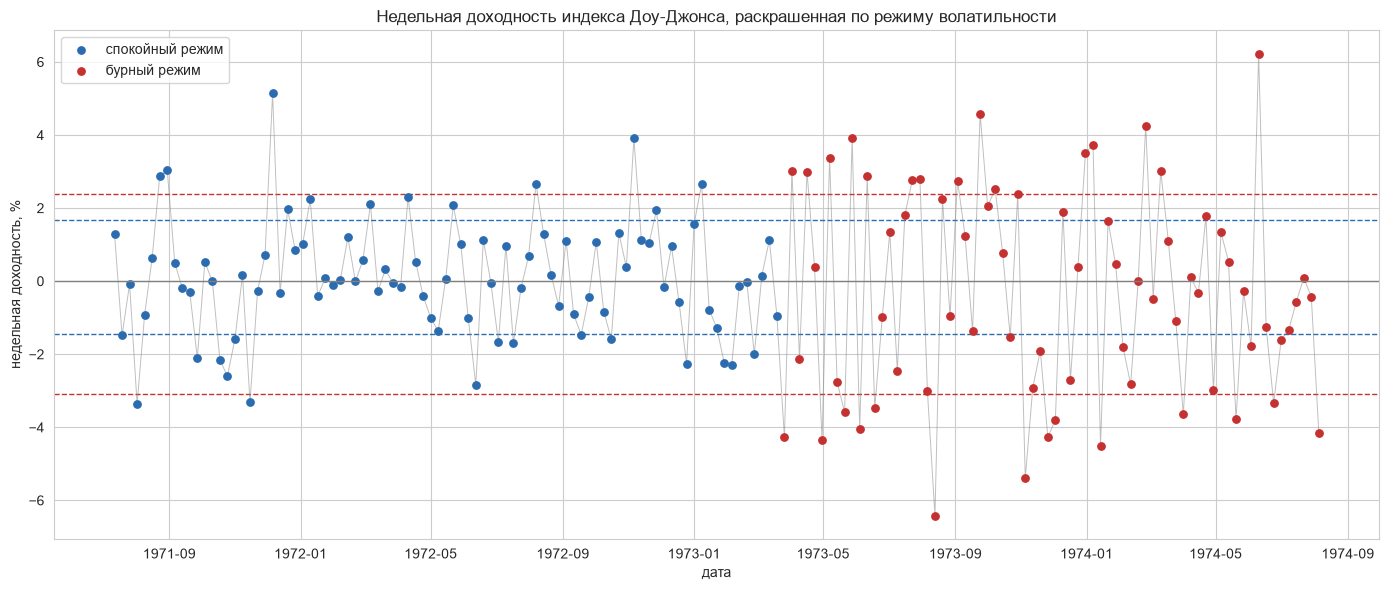

In [17]:
plt.figure(figsize=(14, 6))
for i, (цвет, имя) in enumerate([('#2b6cb0', 'спокойный режим'), ('#c53030', 'бурный режим')]):
    маска = режим == i
    plt.scatter(даты_дох[маска], доходность[маска], color=цвет, s=28, label=имя, zorder=2)
    plt.axhline(средн_дох[i] + волат[i], color=цвет, lw=1, ls='--', zorder=1)
    plt.axhline(средн_дох[i] - волат[i], color=цвет, lw=1, ls='--', zorder=1)
plt.axhline(0, color='gray', lw=1)
plt.plot(даты_дох, доходность, color='gray', lw=0.7, alpha=0.5, zorder=1)
plt.title('Недельная доходность индекса Доу-Джонса, раскрашенная по режиму волатильности')
plt.xlabel('дата')
plt.ylabel('недельная доходность, %')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по режиму волатильности:** здесь критерии расходятся. BIC минимален при
**одном** состоянии (723 против 727 у двух): со своим более строгим штрафом он не
покупает разбиение на режимы - недельная доходность близка к одному нормальному
распределению. AIC выбирает **два** (706 против 716).

Двухсоставная модель при этом осмысленна и устойчива. Одно переключение делит ряд
надвое: **спокойный режим** (средняя доходность +0.11% в неделю, разброс 1.57%) с
середины 1971 до весны 1973 и **бурный** (средняя -0.35%, разброс 2.74%) с
последней недели марта 1973 до конца ряда. В бурном режиме недельная доходность
гуляет от -6.4% до +6.2%, в спокойном почти не выходит за полтора процента.
Вероятность остаться в режиме 0.99-1.00.

Точка перелома - весна 1973 года - совпадает с моделью уровня из Задачи 6 (пик
закончился на рубеже 1972-1973) и с GARCH из прошлой работы модуля, где спокойный
1972 год отделялся от бурного 1973-го. Три разных подхода указывают на один и тот
же момент смены режима. Разбиение тонкое - BIC за него не платит, - но
качественно оно то же, и это ровно то, для чего годится HMM: не предсказать
значение, а заметить, где ряд сменил поведение